# 03 Model purchase propensity

Notebook 03 builds the model evidence and intervention review layer for the GA4 capstone project. It uses the pre-purchase gold tables from Notebook 01 to estimate session-level purchase likelihood, then turns those scores into stage aware review lists for browse drop-off, cart drop-off, and late checkout recovery decisions.

---

## Purpose

- Build a clean session-level modelling table from the processed gold tables
- Train a simple Logistic Regression baseline and a calibrated LightGBM comparison model
- Evaluate held-out performance using PR-AUC, Brier score, precision, recall, and lift
- Keep a compact feature set sensitivity check so the model is explained
- Create a single combined intervention review table with clear score fields and group labels
- Save artefacts to `outputs/scoring` and final dashboard CSVs to `powerbi_extracts/latest`

---

## Process

1. Load the pre-purchase session, funnel, item, and label tables created in Notebook 01.
2. Build a session-level feature table using behavioural, item intensity, funnel progression, and contextual fields.
3. Split the data by week so the final evaluation uses a later hold-out period rather than a random sample.
4. Train the baseline and calibrated LightGBM models, then compare them using ranking focused metrics.
5. Run the feature set sensitivity check to show how much signal comes from behaviour/context before funnel progression is added.
6. Convert the final model scores into clear intervention review groups for browse, cart, and late checkout decisions.
7. Save the full scoring audit file, combined intervention table, grouped model importance, and Power BI CSV outputs.

# 1.0 Data imports and environment setup

In [1]:
#------------------------------------------------------------------------------
# 1.1 Install packages
#------------------------------------------------------------------------------
%pip -q install lightgbm pyarrow

In [2]:
#------------------------------------------------------------------------------
# 1.2 Import libraries and mount Drive
#------------------------------------------------------------------------------
from pathlib import Path
import json, re, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from google.colab import drive
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
try:
    from sklearn.frozen import FrozenEstimator
except Exception:
    FrozenEstimator = None
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

drive.mount("/content/drive", force_remount=True)

# Set notebook display and plotting defaults
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 115, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.titlesize": 12})

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="The `cv='prefit' option is deprecated.*")


Mounted at /content/drive


# 2.0 Load gold tables and create the modelling base

The modelling base joins the pre-purchase gold tables at one row per session. Raw channel values are kept for modelling  while cleaned display labels are added so later tables and charts are easier to interpret.

**Process**:
1. Define the shared project folders, fixed project dateindow, input paths, output paths, and modelling constants.
2. Load the session, funnel feature, item feature, and purchase label parquet files created by Notebook 01.
3. Join the four gold tables at session grain using `user_pseudo_id` and `ga_session_id`.
4. Add compact behavioural features such as event density, engagement per event, and item activity ratios.
5. Keep the raw channel fields for audit and create cleaner display labels for reporting
6. Build the final feature list after excluding IDs, labels, display only fields, and known leakage fields.


In [3]:
#------------------------------------------------------------------------------
# 2.1 Core config and Drive folders
#------------------------------------------------------------------------------
CAPSTONE_DIR = Path("/content/drive/MyDrive/Capstone_Project")
DATA_DIR = CAPSTONE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = CAPSTONE_DIR / "outputs"
SCORING_DIR = OUTPUT_DIR / "scoring"
PBI_LATEST_DIR = CAPSTONE_DIR / "powerbi_extracts" / "latest"

# Create output folders
for p in [OUTPUT_DIR, SCORING_DIR, PBI_LATEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Keep the same source table window across notebooks
START_DATE = "20201101"
END_DATE = "20210228"

SESSIONS_PATH = PROCESSED_DIR / "sessions.parquet"
FUNNEL_FEATURES_PATH = PROCESSED_DIR / "funnel_features.parquet"
ITEMS_SESSION_PATH = PROCESSED_DIR / "items_session.parquet"
SESSION_LABEL_PATH = PROCESSED_DIR / "session_label.parquet"

# Set scoring output paths
SESSION_SCORES_PARQUET_PATH = SCORING_DIR / "session_scores_all.parquet"
COMBINED_PRIORITY_PARQUET_PATH = SCORING_DIR / "combined_priority_candidates.parquet"

# Set Power BI output paths
PBI_MODEL_COMPARISON_PATH = PBI_LATEST_DIR / "model_comparison_metrics.csv"
PBI_RANKING_CUTOFF_PATH = PBI_LATEST_DIR / "ranking_cutoff_metrics.csv"
PBI_GROUPED_IMPORTANCE_PATH = PBI_LATEST_DIR / "grouped_model_importance.csv"
PBI_COMBINED_PRIORITY_PATH = PBI_LATEST_DIR / "combined_priority_candidates.csv"

# Set model and ranking options
RANDOM_STATE = 42
TOP_FRAC = 0.05
RANKING_TOP_FRACS = [0.01, 0.02, 0.05]
RANKING_TOP_NS = [100, 250]
RUN_ABLATIONS = True

# Cap review list sizes within each funnel stage
BROWSE_INTERVENTION_TOP_N = 50
CART_INTERVENTION_TOP_N = 50
LATE_RECOVERY_TOP_N = 100


In [4]:
#------------------------------------------------------------------------------
# 2.2 Compact helpers
#------------------------------------------------------------------------------
# Set display labels for model and review outputs
MODEL_LABEL_MAP = {"logistic_regression": "Logistic regression baseline", "lightgbm_raw": "LightGBM raw score",
                   "lightgbm_calibrated": "LightGBM calibrated likelihood"}
INTERVENTION_LABEL_MAP = {"browse_intervention": "Browse drop-off review", "cart_intervention": "Cart drop-off review",
                          "late_recovery": "Late checkout recovery"}
BAND_LABEL_MAP = {"very_high": "Very high within group", "high": "High within group", "medium": "Medium within group", "review": "Review"}

# Print a clean section banner
def print_banner(title):
    print("\n" + "-" * 78); print(title); print("-" * 78)

# Divide safely when denominators can be zero
def safe_divide(numerator, denominator):
    numerator = pd.Series(numerator, copy=False); denominator = pd.Series(denominator, copy=False)
    return np.where(denominator > 0, numerator / denominator, np.nan)

# Save CSV outputs
def save_csv(df, path):
    path.parent.mkdir(parents=True, exist_ok=True); df.to_csv(path, index=False)

# Save parquet audit outputs
def save_parquet(df, path):
    path.parent.mkdir(parents=True, exist_ok=True); df.to_parquet(path, index=False)

# Show plots without saving extra files
def showfig():
    plt.tight_layout(); plt.show(); plt.close()

# Add value labels to bars
def add_bar_labels(ax, fmt="{:.3f}", horizontal=False):
    for patch in ax.patches:
        if horizontal:
            width = patch.get_width(); y_pos = patch.get_y() + patch.get_height() / 2
            ax.text(width + max(abs(width) * 0.01, 0.00001), y_pos, fmt.format(width), va="center", ha="left", fontsize=9)
        else:
            height = patch.get_height(); x_pos = patch.get_x() + patch.get_width() / 2
            ax.text(x_pos, height + max(abs(height) * 0.01, 0.00001), fmt.format(height), va="bottom", ha="center", fontsize=9)

# Apply repeated chart formatting
def format_axis(ax, title, xlabel, ylabel, percent_y=False, rotate_x=0):
    ax.set_title(title, pad=10); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if percent_y:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    if rotate_x:
        ax.tick_params(axis="x", rotation=rotate_x)

# Clean model labels for tables and charts
def clean_model_label(model_name):
    return MODEL_LABEL_MAP.get(str(model_name), str(model_name).replace("_", " ").title())

# Clean raw channel labels for display
def clean_channel_segment(value):
    raw_value = "(not set) / (not set)" if pd.isna(value) else str(value).strip()
    value_lower = raw_value.lower()
    label_map = {"(direct) / (none)": "Direct traffic", "(not set) / (not set)": "Unknown traffic",
                 "google / organic": "Google organic traffic", "google / cpc": "Google paid search traffic",
                 "analytics.google.com / referral": "Google Analytics referral traffic",
                 "shop.googlemerchandisestore.com / referral": "Google Merch Store referral traffic",
                 "googlemerchandisestore.com / referral": "Google Merch Store referral traffic",
                 "creatoracademy.youtube.com / referral": "YouTube Creator Academy referral traffic",
                 "perksatwork.com / referral": "Perks at Work referral traffic", "yandex.ru / referral": "Yandex referral traffic",
                 "<other> / <other>": "Other channels", "<other> / referral": "Other referral traffic",
                 "<other> / organic": "Other organic traffic", "(data deleted) / (data deleted)": "Unknown traffic",
                 "(data deleted) / organic": "Unknown organic traffic", "(data deleted) / referral": "Unknown referral traffic",
                 "(direct) / organic": "Direct organic traffic", "(direct) / referral": "Direct referral traffic"}
    # Use fixed labels for common traffic values
    if value_lower in label_map:
        return label_map[value_lower]
    if "safeframe" in value_lower or "googlesyndication" in value_lower:
        return "Google ad frame referral traffic"
    if "googleusercontent" in value_lower:
        return "Google hosted referral traffic"
    # Handle source / medium values not covered above
    if " / " in raw_value:
        source, medium = raw_value.split(" / ", 1)
        source_clean = source.strip().lower(); medium_clean = medium.strip().lower()
        if source_clean in ["<other>", "other"]:
            return f"Other {medium_clean} traffic" if medium_clean not in ["<other>", "other"] else "Other channels"
        if source_clean in ["(not set)", "(data deleted)", "data deleted"]:
            return f"Unknown {medium_clean} traffic" if medium_clean not in ["(not set)", "(data deleted)"] else "Unknown traffic"
        if len(source_clean) > 45 or source_clean.count(".") >= 3:
            return f"Other {medium_clean} traffic" if medium_clean not in ["(not set)", "(none)"] else "Other traffic"
        source_display = source_clean.replace("googlemerchandisestore.com", "Google Merch Store").replace("_", " ").replace("-", " ").title()
        medium_display = medium_clean.replace("_", " ")
        return f"{source_display} {medium_display} traffic"
    if len(value_lower) > 45 or value_lower.count(".") >= 3:
        return "Other technical traffic"
    return raw_value.replace("_", " ").replace("-", " ").title()

# Build preprocessing for numeric and categorical fields
def make_preprocessor(num_cols, cat_cols, scale_numeric=False):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler(with_mean=False)))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), list(num_cols)),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), list(cat_cols))])

# Build the LightGBM model setup
def make_lgbm_model(n_estimators=2000):
    return LGBMClassifier(objective="binary", n_estimators=int(n_estimators), learning_rate=0.03, num_leaves=31,
                          min_child_samples=50, subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
                          random_state=RANDOM_STATE, force_col_wise=True, verbosity=-1)

# Clean encoded feature names
def get_clean_feature_names(preprocessor):
    names = preprocessor.get_feature_names_out()
    return [n.replace("num__", "").replace("cat__", "") for n in names]

In [5]:
#------------------------------------------------------------------------------
# 2.3 Metrics, feature group and candidate helpers
#------------------------------------------------------------------------------
# Calculate main model metrics
def calc_binary_metrics(y_true, y_prob, split_name, model_name, top_frac=TOP_FRAC):
    y_true = np.asarray(y_true).astype(int); y_prob = np.asarray(y_prob).astype(float)
    n_obs = len(y_true); n_positive = int(y_true.sum()); prevalence = float(y_true.mean()) if n_obs > 0 else np.nan
    # Keep only the highest scored sessions for top-k metrics
    order = np.argsort(-y_prob); y_top = y_true[order][:max(1, int(np.ceil(n_obs * top_frac)))]
    precision_at_k = float(y_top.mean()) if len(y_top) > 0 else np.nan
    recall_at_k = float(y_top.sum() / n_positive) if n_positive > 0 else np.nan
    lift_at_k = float(precision_at_k / prevalence) if prevalence > 0 else np.nan
    return {"split": split_name, "data_split": split_name, "model": model_name, "n_obs": int(n_obs), "n_positive": int(n_positive),
            "prevalence": prevalence, "pr_auc": float(average_precision_score(y_true, y_prob)) if n_positive > 0 else np.nan,
            "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
            "brier_score": float(brier_score_loss(y_true, y_prob)), "top_frac": float(top_frac), "k_n": int(len(y_top)),
            "precision_at_k": precision_at_k, "recall_at_k": recall_at_k, "lift_at_k": lift_at_k}

# Calculate ranking metrics at review cut-offs
def calc_rank_metrics_at_cutoff(y_true, y_score, split_name, model_name, cutoff_label, top_frac=None, top_n=None):
    y_true = np.asarray(y_true).astype(int); y_score = np.asarray(y_score).astype(float)
    n_obs = len(y_true); n_positive = int(y_true.sum()); prevalence = float(y_true.mean()) if n_obs > 0 else np.nan
    order = np.argsort(-y_score); y_sorted = y_true[order]
    # Choose either a percent cut-off or fixed row count
    if top_frac is not None:
        k = max(1, int(np.ceil(n_obs * float(top_frac)))); cutoff_type = "share"; cutoff_value = float(top_frac)
    elif top_n is not None:
        k = min(n_obs, int(top_n)); cutoff_type = "count"; cutoff_value = int(top_n)
    else:
        raise ValueError("Either top_frac or top_n must be provided.")
    y_top = y_sorted[:k]; precision_at_k = float(y_top.mean()) if len(y_top) > 0 else np.nan
    recall_at_k = float(y_top.sum() / n_positive) if n_positive > 0 else np.nan
    lift_at_k = float(precision_at_k / prevalence) if prevalence > 0 else np.nan
    return {"split": split_name, "data_split": split_name, "model": model_name, "cutoff_label": cutoff_label, "cutoff_type": cutoff_type,
            "cutoff_value": cutoff_value, "n_obs": int(n_obs), "n_positive": int(n_positive), "prevalence": prevalence,
            "k_n": int(k), "positives_captured_n": int(y_top.sum()), "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k, "lift_at_k": lift_at_k}

# Build ranking metrics across models and cut-offs
def build_ranking_cutoff_table(y_true, prediction_dict, split_name, top_fracs=None, top_ns=None):
    rows = []
    for model_name, y_score in prediction_dict.items():
        for top_frac in top_fracs or []:
            rows.append(calc_rank_metrics_at_cutoff(y_true, y_score, split_name, model_name, f"top_{int(top_frac * 100)}pct", top_frac=top_frac))
        for top_n in top_ns or []:
            rows.append(calc_rank_metrics_at_cutoff(y_true, y_score, split_name, model_name, f"top_{top_n}", top_n=top_n))
    return pd.DataFrame(rows)

# Define feature groups used for checks
ENGAGEMENT_FEATURES = {"n_events", "n_distinct_event_names", "session_duration_seconds", "engagement_time_msec_sum",
                       "events_per_event_type", "engagement_time_per_event"}
FUNNEL_PREFIXES = ("reached_", "t_view_", "t_cart_", "t_checkout_", "t_shipping_", "t_payment_")
ITEM_KEYWORDS = ("item", "price", "qty", "basket")

# Map features into simple modelling groups
def get_ablation_block(feature_name):
    if feature_name.startswith("channel_") or feature_name.startswith("geo_") or feature_name.startswith("device_"):
        return "contextual"
    if feature_name in ENGAGEMENT_FEATURES:
        return "engagement"
    if feature_name.startswith(FUNNEL_PREFIXES):
        return "funnel"
    if feature_name == "has_item_activity" or any(k in feature_name for k in ITEM_KEYWORDS):
        return "item"
    return "basic_session"

# Map features into report-friendly groups
def get_interpretability_group(feature_name):
    if feature_name.startswith("channel_"): return "traffic source / medium"
    if feature_name.startswith("geo_"): return "geography"
    if feature_name.startswith("device_"): return "device"
    if get_ablation_block(feature_name) == "funnel": return "funnel progression"
    if get_ablation_block(feature_name) == "item": return "item intensity"
    return "session behaviour"

# Match encoded names back to original fields
def get_original_feature_from_encoded(encoded_feature_name, numeric_cols, categorical_cols):
    if encoded_feature_name in numeric_cols:
        return encoded_feature_name
    for col_name in sorted(categorical_cols, key=len, reverse=True):
        if encoded_feature_name.startswith(f"{col_name}_"):
            return col_name
    return encoded_feature_name

# Add funnel labels to scored sessions
def add_funnel_path_labels(df):
    df = df.copy()
    stage_scan = [("reached_add_payment_info", "add_payment_info", "after_add_payment_info"),
                  ("reached_add_shipping_info", "add_shipping_info", "after_add_shipping_info"),
                  ("reached_begin_checkout", "begin_checkout", "after_begin_checkout"),
                  ("reached_add_to_cart", "add_to_cart", "after_add_to_cart"),
                  ("reached_view_item", "view_item", "after_view_item")]
    # Scan from latest to earliest funnel stage
    conditions = [df[c].fillna(0).eq(1) for c, _, _ in stage_scan]
    df["last_observed_funnel_stage"] = np.select(conditions, [x[1] for x in stage_scan], default="before_view_item")
    df["dropoff_after_stage"] = np.where(df["y_purchase"].fillna(0).astype(int).eq(1), "purchased",
                                         np.select(conditions, [x[2] for x in stage_scan], default="before_view_item"))
    return df

# Flag impossible funnel paths for action outputs
def get_non_monotonic_funnel_mask(df):
    return (((df["reached_add_to_cart"] == 1) & (df["reached_view_item"] == 0)) |
            ((df["reached_begin_checkout"] == 1) & (df["reached_add_to_cart"] == 0)) |
            ((df["reached_add_shipping_info"] == 1) & (df["reached_begin_checkout"] == 0)) |
            ((df["reached_add_payment_info"] == 1) & (df["reached_add_shipping_info"] == 0)))

# Select top sessions inside a candidate group
def select_candidates(df, score_col, top_n):
    return df.sort_values(score_col, ascending=False).head(top_n).reset_index(drop=True).copy()

In [6]:
#------------------------------------------------------------------------------
# 2.4 Load processed gold tables
#------------------------------------------------------------------------------
print_banner("2.4 Load processed gold tables")

# Load processed parquet tables
sessions = pd.read_parquet(SESSIONS_PATH)
funnel_features = pd.read_parquet(FUNNEL_FEATURES_PATH)
items_session = pd.read_parquet(ITEMS_SESSION_PATH)
session_label = pd.read_parquet(SESSION_LABEL_PATH)

# Standardise join key types
for df in [sessions, funnel_features, items_session, session_label]:
    df["user_pseudo_id"] = df["user_pseudo_id"].astype("string")
    df["ga_session_id"] = df["ga_session_id"].astype("string")

# Convert date fields
sessions["week_start_date"] = pd.to_datetime(sessions["week_start_date"])
sessions["session_date"] = pd.to_datetime(sessions["session_date"])

# Summarise loaded table shapes
load_check_df = pd.DataFrame({
    "table":["sessions", "funnel_features", "items_session", "session_label"],
    "rows":[len(sessions), len(funnel_features), len(items_session), len(session_label)],
    "columns":[sessions.shape[1], funnel_features.shape[1], items_session.shape[1], session_label.shape[1]]})

print("Using fixed project date window:", START_DATE, "to", END_DATE)
display(load_check_df)


------------------------------------------------------------------------------
2.4 Load processed gold tables
------------------------------------------------------------------------------
Using fixed project date window: 20201101 to 20210228


,table,rows,columns
0,sessions,360129,26
1,funnel_features,360129,13
2,items_session,360129,10
3,session_label,360129,3


In [7]:
#------------------------------------------------------------------------------
# 2.5 Join gold tables and build modelling features
#------------------------------------------------------------------------------
print_banner("2.5 Join gold tables and build modelling features")

# Join Notebook 01 session grain outputs
model_df = (sessions
            .merge(funnel_features, on=["user_pseudo_id", "ga_session_id"], how="inner")
            .merge(items_session, on=["user_pseudo_id", "ga_session_id"], how="inner")
            .merge(session_label, on=["user_pseudo_id", "ga_session_id"], how="inner")
            .copy())

# Keep the session key and target unchanged
model_df["y_purchase"] = model_df["y_purchase"].astype(int)
model_df["week_start_date"] = pd.to_datetime(model_df["week_start_date"])

# Keep raw channel values and clean display labels
for col in ["channel_source", "channel_medium", "channel_segment"]:
    model_df[col] = model_df[col].fillna("(not set)").astype(str)

model_df["channel_segment_raw"] = model_df["channel_segment"]
model_df["channel_segment_clean"] = model_df["channel_segment_raw"].apply(clean_channel_segment)

# Add compact pre-purchase behavioural ratios
model_df["events_per_event_type"] = safe_divide(model_df["n_events"], model_df["n_distinct_event_names"])
model_df["engagement_time_per_event"] = safe_divide(model_df["engagement_time_msec_sum"], model_df["n_events"])
model_df["has_item_activity"] = (model_df["n_item_rows"] > 0).astype(int)
model_df["item_rows_per_distinct_item"] = np.where(model_df["n_distinct_item_id"] > 0, model_df["n_item_rows"] / model_df["n_distinct_item_id"], 0.0)

# Build a quick model table check
quick_model_check = pd.DataFrame({
    "check":["sessions", "purchases", "purchase_rate", "columns_before_feature_selection"],
    "value":[len(model_df), int(model_df["y_purchase"].sum()), model_df["y_purchase"].mean(), model_df.shape[1]]})

# Preview raw-to-clean channel labels
channel_preview_df = (model_df.groupby(["channel_segment_raw", "channel_segment_clean"], as_index=False)
    .agg(n_sessions=("user_session_key", "nunique"))
    .sort_values("n_sessions", ascending=False))

display(quick_model_check)
print("Channel display mapping used for tables and plots")
display(channel_preview_df.head(20))


------------------------------------------------------------------------------
2.5 Join gold tables and build modelling features
------------------------------------------------------------------------------


,check,value
0,sessions,"360,129.0000"
1,purchases,"4,848.0000"
2,purchase_rate,0.0135
3,columns_before_feature_selection,52.0000


Channel display mapping used for tables and plots


,channel_segment_raw,channel_segment_clean,n_sessions
175,google / organic,Google organic traffic,125911
3,(direct) / (none),Direct traffic,59967
231,shop.googlemerchandisestore.com / referral,Google Merch Store referral traffic,59399
76,<Other> / <Other>,Other channels,39683
78,<Other> / referral,Other referral traffic,29330
173,google / cpc,Google paid search traffic,11947
0,(data deleted) / (data deleted),Unknown traffic,10888
77,<Other> / organic,Other organic traffic,7767
184,googlemerchandisestore.com / referral,Google Merch Store referral traffic,4095
100,analytics.google.com / referral,Google Analytics referral traffic,3412


In [8]:
#------------------------------------------------------------------------------
# 2.6 Define final feature list
#------------------------------------------------------------------------------
print_banner("2.6 Define final feature list")

# Define final model features from gold tables
numeric_cols = [
    "ga_session_number", "session_duration_seconds", "n_events", "n_distinct_event_names", "engagement_time_msec_sum",
    "session_engaged_flag_max", "reached_view_item", "reached_add_to_cart", "reached_begin_checkout",
    "reached_add_shipping_info", "reached_add_payment_info", "t_view_to_cart_sec", "t_cart_to_checkout_sec",
    "t_checkout_to_shipping_sec", "t_shipping_to_payment_sec", "n_item_rows", "n_distinct_item_id",
    "n_distinct_item_category", "avg_item_price", "max_item_price", "qty_sum", "events_per_event_type",
    "engagement_time_per_event", "has_item_activity", "item_rows_per_distinct_item"]

categorical_cols = ["device_category", "device_os", "device_browser", "geo_country", "geo_region","channel_source", "channel_medium", "channel_segment"]

# Combine numeric and categorical features
FEATURE_COLS = numeric_cols + categorical_cols

# Map each feature to a simple group
feature_group_map_df = pd.DataFrame({"original_feature":FEATURE_COLS})
feature_group_map_df["ablation_block"] = feature_group_map_df["original_feature"].apply(get_ablation_block)
feature_group_map_df["interpretability_group"] = feature_group_map_df["original_feature"].apply(get_interpretability_group)

# Summarise feature counts
feature_type_df = pd.DataFrame({
    "feature_type":["numeric", "categorical", "total"],
    "n_features":[len(numeric_cols), len(categorical_cols), len(FEATURE_COLS)]})

# Summarise feature groups
feature_summary_df = (feature_group_map_df.groupby(["ablation_block", "interpretability_group"], as_index=False)
    .agg(n_features=("original_feature", "count"))
    .sort_values(["ablation_block", "interpretability_group"]))

print("Feature type summary")
display(feature_type_df)
print("\n")
print("Feature group summary")
display(feature_summary_df)


------------------------------------------------------------------------------
2.6 Define final feature list
------------------------------------------------------------------------------
Feature type summary


,feature_type,n_features
0,numeric,25
1,categorical,8
2,total,33




Feature group summary


,ablation_block,interpretability_group,n_features
0,basic_session,session behaviour,2
1,contextual,device,3
2,contextual,geography,2
3,contextual,traffic source / medium,3
4,engagement,session behaviour,6
5,funnel,funnel progression,9
6,item,item intensity,8


# 3.0 Create the time based split

A week based split gives the evaluation a more realistic structure than a random train test split. Earlier weeks are used for training, the next week supports calibration and validation, and the final week is held out for the main test results.

**Process**:
1. Sort the available `week_start_date` values from the session-level modelling table.
2. Assign earlier weeks to training, the second last week to validation, and the final week to testing.
3. Create separate training, validation, and test DataFrames using the same feature list.
4. Build preprocessing matrices for numeric and categorical fields without changing the session grain.
5. Display the split sizes and purchase rates so class imbalance is visible before modelling.



------------------------------------------------------------------------------
3.1 Create a time-based split
------------------------------------------------------------------------------


,data_split,week_start_date,n_sessions,purchases,purchase_rate
1,train,2020-10-26,2625,13,0.0050
2,train,2020-11-02,24991,249,0.0100
3,train,2020-11-09,22508,341,0.0152
4,train,2020-11-16,25914,374,0.0144
5,train,2020-11-23,27780,515,0.0185
6,train,2020-11-30,31088,590,0.0190
7,train,2020-12-07,38729,772,0.0199
8,train,2020-12-14,33411,549,0.0164
9,train,2020-12-21,22083,233,0.0106
10,train,2020-12-28,20444,138,0.0068


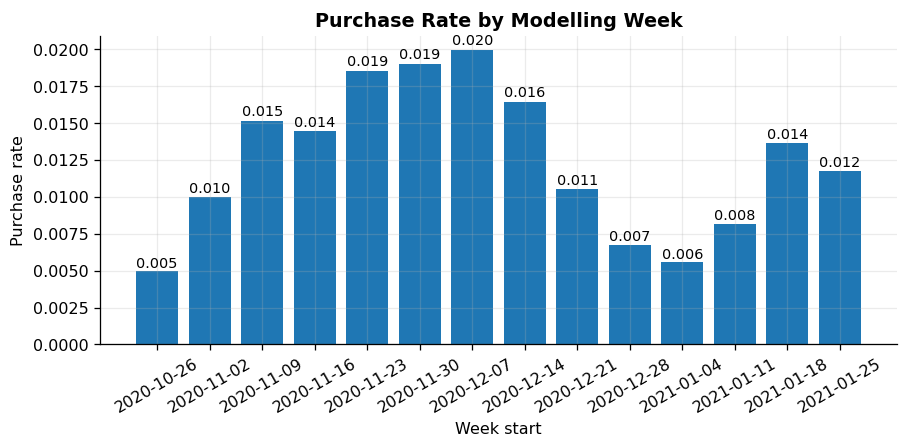

In [9]:
#------------------------------------------------------------------------------
# 3.1 Create a time-based split
#------------------------------------------------------------------------------
print_banner("3.1 Create a time-based split")

# Select train, validation and test weeks
unique_weeks = sorted(model_df["week_start_date"].dropna().unique())
train_weeks = unique_weeks[:-2]; val_week = unique_weeks[-2]; test_week = unique_weeks[-1]

# Assign each session to a time split
model_df["data_split"] = "train"
model_df.loc[model_df["week_start_date"].eq(val_week), "data_split"] = "validation"
model_df.loc[model_df["week_start_date"].eq(test_week), "data_split"] = "test"

# Create split DataFrames
train_df = model_df[model_df["data_split"].eq("train")].copy()
val_df = model_df[model_df["data_split"].eq("validation")].copy()
test_df = model_df[model_df["data_split"].eq("test")].copy()

# Summarise weekly split sizes and purchase rates
split_summary_df = (model_df.groupby(["data_split","week_start_date"], as_index=False)
                    .agg(n_sessions=("user_session_key", "count"), purchases=("y_purchase", "sum"), purchase_rate=("y_purchase", "mean"))
                    .sort_values(["week_start_date","data_split"]))
display(split_summary_df)
print('\n')
# Plot purchase rate by modelling week
plot_split_df = split_summary_df.copy(); plot_split_df["week_label"] = plot_split_df["week_start_date"].dt.strftime("%Y-%m-%d")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_split_df["week_label"], plot_split_df["purchase_rate"])
ax.set_title("Purchase Rate by Modelling Week")
ax.set_xlabel("Week start")
ax.set_ylabel("Purchase rate")
ax.tick_params(axis="x", rotation=30)
add_bar_labels(ax, fmt="{:.3f}")
showfig()

**Summary of time based split outputs:**
1. **Weekly purchase rates vary:** The purchase rate rises through late November and early December, then drops around late December and early January before increasing again in the validation period. The final test week remains above the early January low but is slightly lower than validation, so model performance should be interpreted as future period ranking performance rather than a perfectly stable estimate of conversion behaviour.

In [10]:
#------------------------------------------------------------------------------
# 3.2 Build matrices and preprocessing objects
#------------------------------------------------------------------------------
print_banner("3.2 Build matrices and preprocessing objects")

# Build features and labels for each split
X_train = train_df[FEATURE_COLS].copy(); y_train = train_df["y_purchase"].astype(int)
X_val = val_df[FEATURE_COLS].copy(); y_val = val_df["y_purchase"].astype(int)
X_test = test_df[FEATURE_COLS].copy(); y_test = test_df["y_purchase"].astype(int)

# Build separate preprocessors for each model type
logreg_preprocessor = make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)
lgbm_preprocessor = make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False)

# Fit preprocessing on train and transform all splits
X_train_log = logreg_preprocessor.fit_transform(X_train); X_val_log = logreg_preprocessor.transform(X_val); X_test_log = logreg_preprocessor.transform(X_test)
X_train_lgb = lgbm_preprocessor.fit_transform(X_train); X_val_lgb = lgbm_preprocessor.transform(X_val); X_test_lgb = lgbm_preprocessor.transform(X_test)
lgbm_encoded_feature_names = get_clean_feature_names(lgbm_preprocessor)

# Check matrix sizes before modelling
matrix_check_df = pd.DataFrame({"matrix": ["X_train", "X_validation", "X_test", "X_train_encoded_lgbm"],
                                "rows": [X_train.shape[0], X_val.shape[0], X_test.shape[0], X_train_lgb.shape[0]],
                                "columns": [X_train.shape[1], X_val.shape[1], X_test.shape[1], X_train_lgb.shape[1]]})
display(matrix_check_df)



------------------------------------------------------------------------------
3.2 Build matrices and preprocessing objects
------------------------------------------------------------------------------


,matrix,rows,columns
0,X_train,306309,33
1,X_validation,27478,33
2,X_test,26342,33
3,X_train_encoded_lgbm,306309,970


# 4.0 Train baseline and final model

The baseline is kept as a simple reference point, while LightGBM is used to capture non-linear relationships across pre-purchase behaviour, item interest, funnel progress, and context. The final score is treated as a session-level purchase likelihood score and not as an early prediction claim.

**Process**:
1. Fit a class weighted Logistic Regression baseline on the same modelling table.
2. Fit a LightGBM model using the pre-purchase feature set.
3. Calibrate the LightGBM model on the validation week so the score is easier to interpret as purchase likelihood.
4. Calculate validation and test metrics for the baseline, raw LightGBM score, and calibrated LightGBM score.
5. Create ranking cut-off tables for practical review lists such as Top 1%, Top 5%, Top 100, and Top 250 sessions.


In [11]:
#------------------------------------------------------------------------------
# 4.1 Train the baseline and main LightGBM model
#------------------------------------------------------------------------------
print_banner("4.1 Train the baseline and main LightGBM model")

# Train baseline model for comparison
logreg_model = LogisticRegression(class_weight="balanced", max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)
logreg_model.fit(X_train_log, y_train)
val_pred_logreg = logreg_model.predict_proba(X_val_log)[:, 1]
test_pred_logreg = logreg_model.predict_proba(X_test_log)[:, 1]

# Train main LightGBM model for ranking
lgbm_model = make_lgbm_model(n_estimators=2000)
lgbm_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)], eval_metric="average_precision",
               callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)])
val_pred_lgb = lgbm_model.predict_proba(X_val_lgb)[:, 1]
test_pred_lgb = lgbm_model.predict_proba(X_test_lgb)[:, 1]

# Calibrate scores for easier interpretation
if FrozenEstimator is not None:
    lgbm_calibrator = CalibratedClassifierCV(estimator=FrozenEstimator(lgbm_model), method="sigmoid")
else:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="The `cv='prefit' option is deprecated.*")
        lgbm_calibrator = CalibratedClassifierCV(estimator=lgbm_model, method="sigmoid", cv="prefit")
lgbm_calibrator.fit(X_val_lgb, y_val)
val_pred_lgb_cal = lgbm_calibrator.predict_proba(X_val_lgb)[:, 1]
test_pred_lgb_cal = lgbm_calibrator.predict_proba(X_test_lgb)[:, 1]

# Compare validation and test metrics
model_comparison_df = pd.DataFrame([
    calc_binary_metrics(y_val, val_pred_logreg, "validation", "logistic_regression"),
    calc_binary_metrics(y_val, val_pred_lgb, "validation", "lightgbm_raw"),
    calc_binary_metrics(y_val, val_pred_lgb_cal, "validation", "lightgbm_calibrated"),
    calc_binary_metrics(y_test, test_pred_logreg, "test", "logistic_regression"),
    calc_binary_metrics(y_test, test_pred_lgb, "test", "lightgbm_raw"),
    calc_binary_metrics(y_test, test_pred_lgb_cal, "test", "lightgbm_calibrated")])
model_comparison_df["model_display_name"] = model_comparison_df["model"].apply(clean_model_label)

# Build ranking cut-off metrics
ranking_cutoff_metrics_df = pd.concat([
    build_ranking_cutoff_table(y_val, {"logistic_regression": val_pred_logreg, "lightgbm_raw": val_pred_lgb,
                                       "lightgbm_calibrated": val_pred_lgb_cal}, "validation", RANKING_TOP_FRACS, RANKING_TOP_NS),
    build_ranking_cutoff_table(y_test, {"logistic_regression": test_pred_logreg, "lightgbm_raw": test_pred_lgb,
                                        "lightgbm_calibrated": test_pred_lgb_cal}, "test", RANKING_TOP_FRACS, RANKING_TOP_NS)], ignore_index=True)
ranking_cutoff_metrics_df["model_display_name"] = ranking_cutoff_metrics_df["model"].apply(clean_model_label)

print("Held-out test model metrics")
test_model_display_df = model_comparison_df[model_comparison_df["data_split"].eq("test")].copy()
display(test_model_display_df[["model_display_name","n_obs","n_positive","prevalence","pr_auc","roc_auc","brier_score","precision_at_k","recall_at_k","lift_at_k"]]
        .sort_values("pr_auc", ascending=False))
print("Ranking cut-off metrics for LightGBM calibrated likelihood")
display(ranking_cutoff_metrics_df[(ranking_cutoff_metrics_df["data_split"].eq("test")) &
                                  (ranking_cutoff_metrics_df["model"].eq("lightgbm_calibrated"))]
        [["model_display_name","cutoff_label","k_n","precision_at_k","recall_at_k","lift_at_k","positives_captured_n","n_positive"]])



------------------------------------------------------------------------------
4.1 Train the baseline and main LightGBM model
------------------------------------------------------------------------------
Held-out test model metrics


,model_display_name,n_obs,n_positive,prevalence,pr_auc,roc_auc,brier_score,precision_at_k,recall_at_k,lift_at_k
4,LightGBM raw score,26342,310,0.0118,0.8039,0.9984,0.1375,0.2352,1.0000,19.9863
5,LightGBM calibrated likelihood,26342,310,0.0118,0.8039,0.9984,0.0031,0.2352,1.0000,19.9863
3,Logistic regression baseline,26342,310,0.0118,0.7871,0.9983,0.0044,0.2352,1.0000,19.9863


Ranking cut-off metrics for LightGBM calibrated likelihood


,model_display_name,cutoff_label,k_n,precision_at_k,recall_at_k,lift_at_k,positives_captured_n,n_positive
25,LightGBM calibrated likelihood,top_1pct,264,0.8106,0.6903,68.8806,214,310
26,LightGBM calibrated likelihood,top_2pct,527,0.5882,1.0000,49.9848,310,310
27,LightGBM calibrated likelihood,top_5pct,1318,0.2352,1.0000,19.9863,310,310
28,LightGBM calibrated likelihood,top_100,100,0.8500,0.2742,72.2281,85,310
29,LightGBM calibrated likelihood,top_250,250,0.8160,0.6581,69.3389,204,310


**Summary of baseline and LightGBM model outputs:**
1. **Model performance:** The calibrated LightGBM model performs slightly better than the logistic regression baseline, with a higher PR-AUC (`0.8039` compared with `0.7870`). This suggests that the non-linear model captures additional structure in the pre-purchase behavioural and contextual features beyond the simpler baseline.

2. **Calibration:** Calibration does not change the ranking performance, but it substantially improves the Brier score compared with the raw LightGBM output (`0.0031` compared with `0.1375`). This makes the final score more appropriate for reporting as purchase likelihood, not only as a raw ranking score.

3. **Prioritisation value:** The ranking results show that the model is most useful as a prioritisation tool. The top `1%` of sessions captures `214` of `310` purchases with `81.1%` precision, while the top `100` sessions achieve `85.0%` precision, supporting its use for focused review lists rather than broad prediction across all sessions.

# 5.0 Evaluate model performance

The evaluation checks whether the model creates useful review lists, with less emphasis on overall accuracy. PR-AUC, lift, and precision at review cut-offs are emphasised because the purchase label is rare and the final dashboard needs prioritised lists.

**Process**:
1. Summarise held-out test performance for the baseline and LightGBM models.
2. Compare calibrated model precision and lift across the configured review cut-offs.
3. Display Brier score so calibration quality remains visible without adding another complex modelling section.
4. Use labelled charts and compact tables so the main performance patterns are clear at a glance.
5. Keep the output focused on model evidence that can be explained in the final report and dashboard.



------------------------------------------------------------------------------
5.1 Display compact model performance visuals
------------------------------------------------------------------------------
Held-out test model summary


,model_display_name,n_obs,n_positive,prevalence,pr_auc,roc_auc,brier_score,precision_at_k,recall_at_k,lift_at_k
4,LightGBM raw score,26342,310,0.0118,0.8039,0.9984,0.1375,0.2352,1.0000,19.9863
5,LightGBM calibrated likelihood,26342,310,0.0118,0.8039,0.9984,0.0031,0.2352,1.0000,19.9863
3,Logistic regression baseline,26342,310,0.0118,0.7871,0.9983,0.0044,0.2352,1.0000,19.9863




LightGBM calibrated likelihood review cut-offs


,cutoff_label,k_n,precision_at_k,recall_at_k,lift_at_k,positives_captured_n,n_positive
25,top_1pct,264,0.8106,0.6903,68.8806,214,310
26,top_2pct,527,0.5882,1.0000,49.9848,310,310
27,top_5pct,1318,0.2352,1.0000,19.9863,310,310
28,top_100,100,0.8500,0.2742,72.2281,85,310
29,top_250,250,0.8160,0.6581,69.3389,204,310


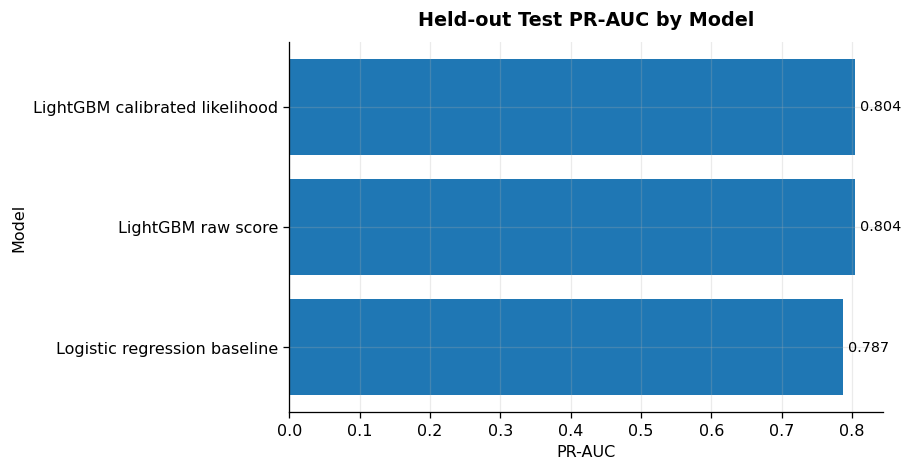

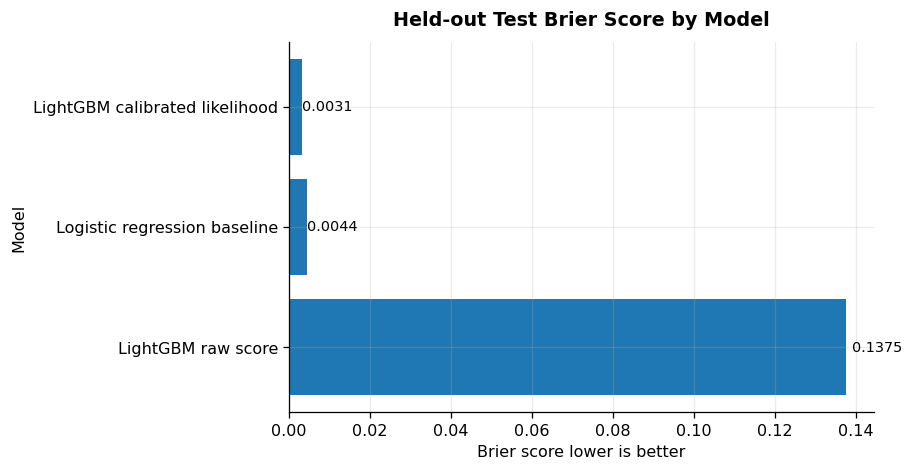

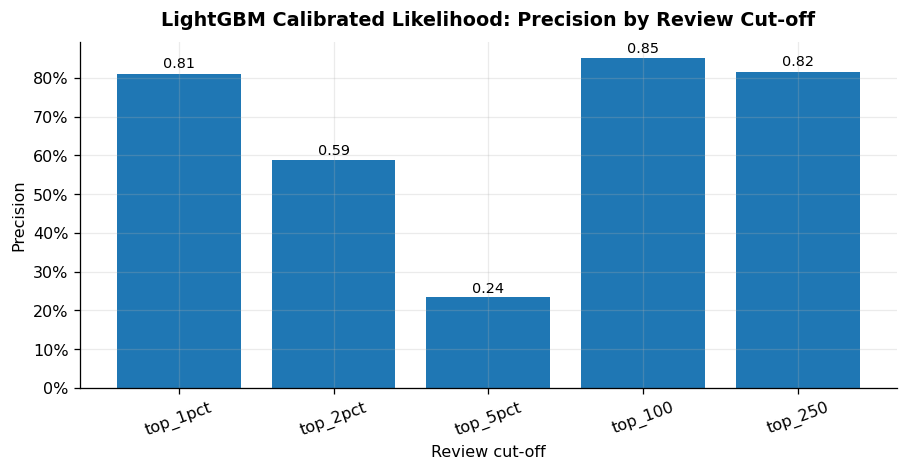

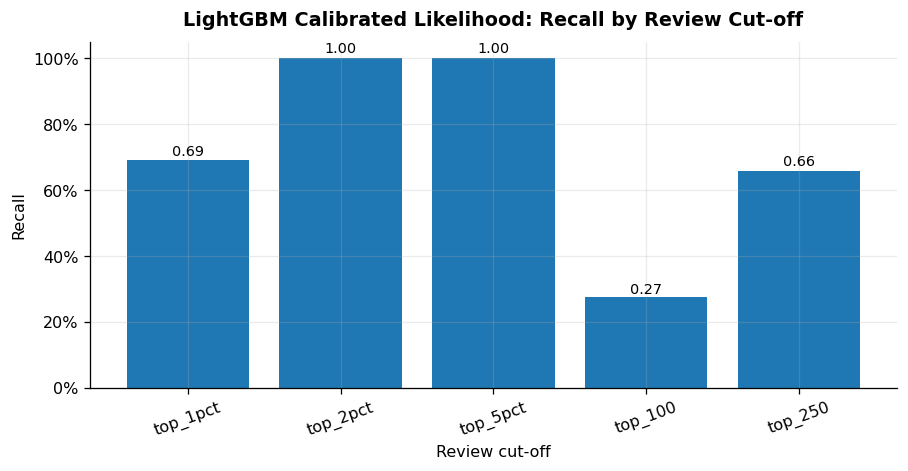

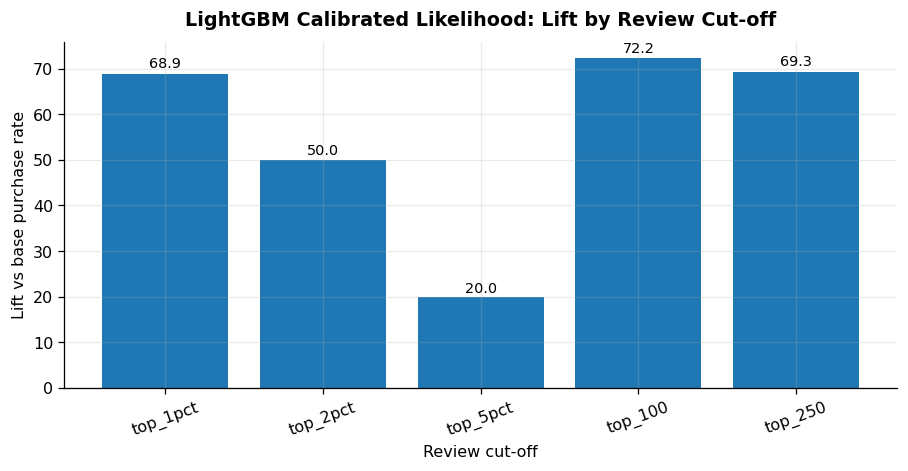

In [12]:
#------------------------------------------------------------------------------
# 5.1 Display compact model performance visuals
#------------------------------------------------------------------------------
print_banner("5.1 Display compact model performance visuals")

# Prepare test metric tables
test_metrics_df = model_comparison_df[model_comparison_df["data_split"].eq("test")].copy()
test_metrics_df["model_display_name"] = test_metrics_df["model"].apply(clean_model_label)
plot_precision_df = ranking_cutoff_metrics_df[(ranking_cutoff_metrics_df["data_split"].eq("test")) &
                                              (ranking_cutoff_metrics_df["model"].eq("lightgbm_calibrated"))].copy()
# Order cut-offs from narrow to wider review lists
cutoff_order = {"top_1pct": 1, "top_2pct": 2, "top_5pct": 3, "top_100": 4, "top_250": 5}
plot_precision_df["cutoff_order"] = plot_precision_df["cutoff_label"].map(cutoff_order).fillna(99)
plot_precision_df = plot_precision_df.sort_values("cutoff_order")

# Select compact display columns
test_summary_cols = ["model_display_name", "n_obs", "n_positive", "prevalence", "pr_auc", "roc_auc", "brier_score", "precision_at_k", "recall_at_k", "lift_at_k"]
test_summary_display_df = test_metrics_df[test_summary_cols].sort_values("pr_auc", ascending=False).round(4)
rank_summary_display_df = plot_precision_df[["cutoff_label", "k_n", "precision_at_k", "recall_at_k", "lift_at_k", "positives_captured_n", "n_positive"]].round(4)

print("Held-out test model summary")
display(test_summary_display_df)
print("\n")
print("LightGBM calibrated likelihood review cut-offs")
display(rank_summary_display_df)
print("\n")

# Plot PR-AUC because purchases are rare
plot_metric_df = test_metrics_df.sort_values("pr_auc", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(plot_metric_df["model_display_name"], plot_metric_df["pr_auc"])
format_axis(ax, "Held-out Test PR-AUC by Model", "PR-AUC", "Model")
add_bar_labels(ax, fmt="{:.3f}", horizontal=True)
showfig()
print("\n")

# Plot Brier score to check calibration
plot_brier_df = test_metrics_df.sort_values("brier_score", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(plot_brier_df["model_display_name"], plot_brier_df["brier_score"])
format_axis(ax, "Held-out Test Brier Score by Model", "Brier score lower is better", "Model")
add_bar_labels(ax, fmt="{:.4f}", horizontal=True)
showfig()
print("\n")

# Plot precision across review cut-offs
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(plot_precision_df["cutoff_label"], plot_precision_df["precision_at_k"])
format_axis(ax, "LightGBM Calibrated Likelihood: Precision by Review Cut-off", "Review cut-off", "Precision", percent_y=True, rotate_x=20)
add_bar_labels(ax, fmt="{:.2f}")
showfig()
print("\n")

# Plot recall across review cut-offs
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(plot_precision_df["cutoff_label"], plot_precision_df["recall_at_k"])
format_axis(ax, "LightGBM Calibrated Likelihood: Recall by Review Cut-off", "Review cut-off", "Recall", percent_y=True, rotate_x=20)
add_bar_labels(ax, fmt="{:.2f}")
showfig()
print("\n")

# Plot lift against random review
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(plot_precision_df["cutoff_label"], plot_precision_df["lift_at_k"])
format_axis(ax, "LightGBM Calibrated Likelihood: Lift by Review Cut-off", "Review cut-off", "Lift vs base purchase rate", rotate_x=20)
add_bar_labels(ax, fmt="{:.1f}")
showfig()
print("\n")


**Summary of model performance outputs:**
1. **LightGBM provides the strongest final model** The calibrated LightGBM model achieves the same PR-AUC as the raw LightGBM model (`0.8039`) and performs slightly better than logistic regression (`0.7870`). Calibration mainly improves score interpretation by reducing the Brier score from `0.1375` to `0.0031`.

2. **The model is most useful for focused review lists rather than broad prediction:** The top `100` sessions achieve `85.0%` precision and the top `1%` captures `214` of `310` purchases with `81.1%` precision, showing that the model is effective at concentrating likely purchasers near the top of the ranked list.

3. **Review list size changes the precision-recall trade-off:** Smaller cut-offs such as the top `100` and top `1%` provide higher precision. Broader cut-offs such as the top `2%` and top `5%` capture more purchases but include more non-purchasing sessions.

# 6.0 Interpret final model signals

The interpretation checks whether the final LightGBM model is using plausible pre-purchase signals rather than relying only on near-purchase funnel indicators. The sensitivity check compares progressively richer feature sets, while grouped feature importance summarises which types of variables contributed most to the final model.

**Process**:
1. Run a compact feature set sensitivity check when `RUN_ABLATIONS` is enabled.
2. Compare behaviour only, behaviour plus context, and full pre-purchase feature sets to check whether useful signal exists before funnel progression is added.
3. Use the final LightGBM feature importance values to group model signal into session behaviour, item intensity, funnel progression, device, geography, and traffic source.
4. Keep encoded feature importance as an audit table, while using grouped importance for the clearer modelling story.
5. Review feature names directly so leakage or target proximity concerns remain visible.


------------------------------------------------------------------------------
6.1 Compact feature sensitivity check
------------------------------------------------------------------------------
Compact sensitivity check


,model_version,feature_groups,n_features,test_pr_auc,test_roc_auc,precision_top_100,lift_top_100,interpretation
0,behaviour_context_funnel,full valid pre-purchase model including funnel progress,33,0.8039,0.9984,0.8500,72.2281,checks the extra gain from valid pre-purchase funnel progress
1,behaviour_context,"behaviour plus device, country and channel context",24,0.7230,0.9962,0.8500,72.2281,checks whether context improves prioritisation
2,behaviour_only,session and item behaviour only,16,0.7126,0.9959,0.8200,69.6788,checks whether behaviour alone has intent signal


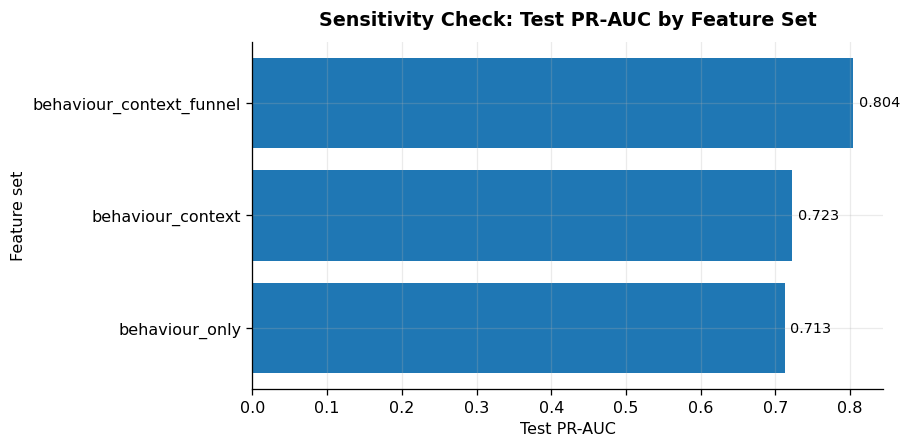

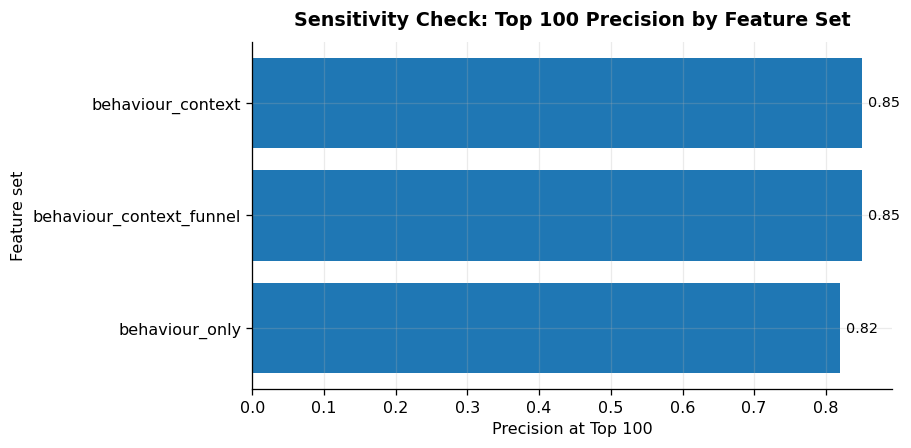

In [13]:
#------------------------------------------------------------------------------
# 6.1 Compact feature sensitivity check
#------------------------------------------------------------------------------
print_banner("6.1 Compact feature sensitivity check")

# Fit LightGBM on one feature subset
def fit_lgbm_subset_model(feature_cols_subset):
    subset_num = [c for c in feature_cols_subset if c in numeric_cols]
    subset_cat = [c for c in feature_cols_subset if c in categorical_cols]
    subset_preprocessor = make_preprocessor(subset_num, subset_cat, scale_numeric=False)
    X_train_sub = subset_preprocessor.fit_transform(train_df[feature_cols_subset])
    X_val_sub = subset_preprocessor.transform(val_df[feature_cols_subset])
    X_test_sub = subset_preprocessor.transform(test_df[feature_cols_subset])
    subset_model = make_lgbm_model(n_estimators=1000)
    subset_model.fit(X_train_sub, y_train, eval_set=[(X_val_sub, y_val)], eval_metric="average_precision",
                     callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)])
    return subset_model.predict_proba(X_val_sub)[:, 1], subset_model.predict_proba(X_test_sub)[:, 1]

# Pull feature columns by group
context_cols = feature_group_map_df.loc[feature_group_map_df["ablation_block"].eq("contextual"), "original_feature"].tolist()
basic_cols = feature_group_map_df.loc[feature_group_map_df["ablation_block"].eq("basic_session"), "original_feature"].tolist()
engagement_cols = feature_group_map_df.loc[feature_group_map_df["ablation_block"].eq("engagement"), "original_feature"].tolist()
funnel_cols = feature_group_map_df.loc[feature_group_map_df["ablation_block"].eq("funnel"), "original_feature"].tolist()
item_cols = feature_group_map_df.loc[feature_group_map_df["ablation_block"].eq("item"), "original_feature"].tolist()

# Build the ablation feature sets
behaviour_cols = [c for c in FEATURE_COLS if c in set(basic_cols + engagement_cols + item_cols)]
behaviour_context_cols = [c for c in FEATURE_COLS if c in set(behaviour_cols + context_cols)]
full_feature_cols = FEATURE_COLS.copy()
ablation_feature_sets = {"behaviour_only": behaviour_cols, "behaviour_context": behaviour_context_cols,
                         "behaviour_context_funnel": full_feature_cols}
feature_set_purpose = {"behaviour_only": "session and item behaviour only",
                       "behaviour_context": "behaviour plus device, country and channel context",
                       "behaviour_context_funnel": "full valid pre-purchase model including funnel progress"}

# Run ablations when enabled
if RUN_ABLATIONS:
    ablation_rows = []
    for model_name, subset_cols in ablation_feature_sets.items():
        val_pred_sub, test_pred_sub = fit_lgbm_subset_model(subset_cols)
        top100_metrics = calc_rank_metrics_at_cutoff(y_test, test_pred_sub, "test", model_name, "top_100", top_n=100)
        ablation_rows.append({"model_version": model_name, "feature_groups": feature_set_purpose[model_name],
                              "n_features": len(subset_cols), "test_pr_auc": average_precision_score(y_test, test_pred_sub),
                              "test_roc_auc": roc_auc_score(y_test, test_pred_sub),
                              "precision_top_100": top100_metrics["precision_at_k"], "lift_top_100": top100_metrics["lift_at_k"]})
    # Summarise feature-set results
    ablation_summary_df = pd.DataFrame(ablation_rows).sort_values("test_pr_auc", ascending=False).reset_index(drop=True)
    ablation_summary_df["interpretation"] = np.select(
        [ablation_summary_df["model_version"].eq("behaviour_only"), ablation_summary_df["model_version"].eq("behaviour_context"),
         ablation_summary_df["model_version"].eq("behaviour_context_funnel")],
        ["checks whether behaviour alone has intent signal", "checks whether context improves prioritisation",
         "checks the extra gain from valid pre-purchase funnel progress"], default="")
    print("Compact sensitivity check")
    display(ablation_summary_df)

    # Plot PR-AUC by feature set
    plot_ablation_df = ablation_summary_df.sort_values("test_pr_auc", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(plot_ablation_df["model_version"], plot_ablation_df["test_pr_auc"])
    format_axis(ax, "Sensitivity Check: Test PR-AUC by Feature Set", "Test PR-AUC", "Feature set")
    add_bar_labels(ax, fmt="{:.3f}", horizontal=True)
    showfig()

    # Plot Top 100 precision by feature set
    plot_top100_df = ablation_summary_df.sort_values("precision_top_100", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(plot_top100_df["model_version"], plot_top100_df["precision_top_100"])
    format_axis(ax, "Sensitivity Check: Top 100 Precision by Feature Set", "Precision at Top 100", "Feature set")
    add_bar_labels(ax, fmt="{:.2f}", horizontal=True)
    showfig()
else:
    ablation_summary_df = pd.DataFrame()
    print("RUN_ABLATIONS is False, so the compact sensitivity check was skipped.")


**Summary of feature sensitivity outputs:**
1. **The model has useful signal before funnel features are added:** Behaviour-only features achieve a test PR-AUC of `0.713` and Top 100 precision of `0.82`. Adding funnel progression increases PR-AUC to `0.804`, showing that funnel features strengthen the model but are not the only source of signal.



------------------------------------------------------------------------------
6.2 Grouped model importance
------------------------------------------------------------------------------


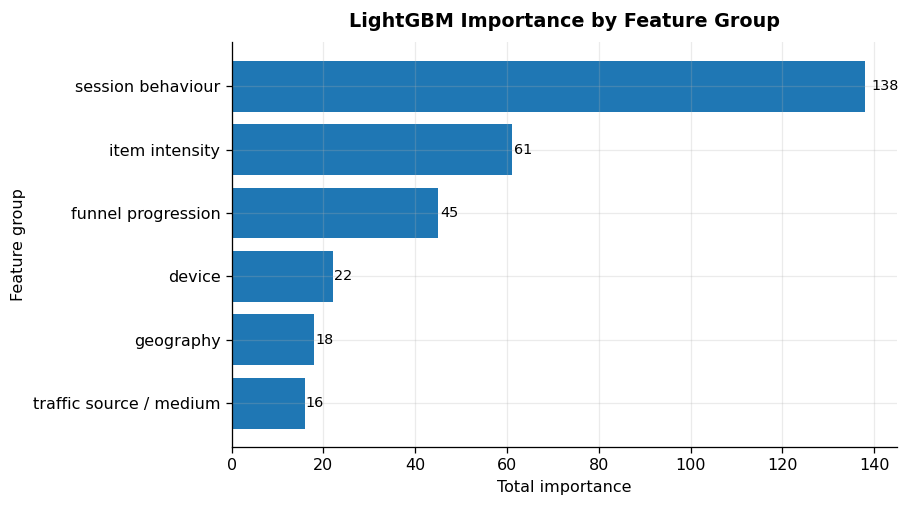

Grouped model importance


,feature_group,importance,importance_share
0,session behaviour,138,0.4600
1,item intensity,61,0.2033
2,funnel progression,45,0.1500
3,device,22,0.0733
4,geography,18,0.0600
5,traffic source / medium,16,0.0533


Top encoded features kept for audit only


,feature,original_feature,feature_group,importance
0,session_duration_seconds,session_duration_seconds,session behaviour,35
1,engagement_time_per_event,engagement_time_per_event,session behaviour,27
2,n_events,n_events,session behaviour,24
3,engagement_time_msec_sum,engagement_time_msec_sum,session behaviour,21
4,events_per_event_type,events_per_event_type,session behaviour,17
5,avg_item_price,avg_item_price,item intensity,16
6,qty_sum,qty_sum,item intensity,15
7,t_cart_to_checkout_sec,t_cart_to_checkout_sec,funnel progression,14
8,ga_session_number,ga_session_number,session behaviour,12
9,reached_add_payment_info,reached_add_payment_info,funnel progression,10


In [14]:
#------------------------------------------------------------------------------
# 6.2 Grouped model importance
#------------------------------------------------------------------------------
print_banner("6.2 Grouped model importance")

# Get encoded LightGBM feature names
lgbm_feature_names = lgbm_encoded_feature_names if "lgbm_encoded_feature_names" in globals() else get_clean_feature_names(lgbm_preprocessor)
feature_importance_df = pd.DataFrame({"feature": lgbm_feature_names, "encoded_feature_name": lgbm_feature_names,
                                      "importance": lgbm_model.feature_importances_})
# Map encoded features back to original fields
feature_importance_df["original_feature"] = feature_importance_df["encoded_feature_name"].apply(
    lambda x: get_original_feature_from_encoded(x, numeric_cols, categorical_cols))
feature_importance_df["feature_group"] = feature_importance_df["original_feature"].apply(get_interpretability_group)
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Summarise importance by feature group
grouped_model_importance_df = (feature_importance_df.groupby("feature_group", as_index=False)["importance"]
                               .sum().sort_values("importance", ascending=False).reset_index(drop=True))
grouped_model_importance_df["importance_share"] = grouped_model_importance_df["importance"] / grouped_model_importance_df["importance"].sum()

# Plot grouped model importance
plot_importance_df = grouped_model_importance_df.sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_importance_df["feature_group"], plot_importance_df["importance"])
format_axis(ax, "LightGBM Importance by Feature Group", "Total importance", "Feature group")
add_bar_labels(ax, fmt="{:.0f}", horizontal=True)
showfig()

print("Grouped model importance")
display(grouped_model_importance_df.round({"importance_share": 4}))
print("Top encoded features kept for audit only")
display(feature_importance_df[["feature", "original_feature", "feature_group", "importance"]].head(15))


**Summary of grouped model importance outputs:**
1. **The model is mainly driven by behavioural signals:** Session behaviour contributes the most importance (`46.0%`), followed by item intensity (`20.3%`) and funnel progression (`15.0%`), showing that the model is learning mostly from pre-purchase engagement and product interest signals.


# 7.0 Create intervention review groups

The final score table is converted into practical intervention review groups, avoiding one undifferentiated ranked list. This avoids letting late checkout sessions dominate every output and makes the candidate table more useful for browse, cart, and checkout recovery decisions. Browse and cart groups are treated as diagnostic review lists, while late checkout recovery is the clearest high likelihood recovery group.

**Process**:
1. Score every session with the final calibrated LightGBM model.
2. Store the calibrated output as `purchase_likelihood_score`, which is the probability style model score.
3. Store a separate `model_ranking_score` for ranking sessions within each intervention group.
4. Build non-purchasing test-session pools for browse drop-off, cart drop-off, and late checkout recovery.
5. Rank sessions within each intervention group using `within_group_priority_score` and `within_group_priority_rank`.
6. Save clear group labels and score-scope fields so Power BI users do not confuse within group priority with purchase probability.


In [15]:
#------------------------------------------------------------------------------
# 7.1 Score all sessions
#------------------------------------------------------------------------------
print_banner("7.1 Score all sessions")

# Transform all sessions for scoring
X_all = model_df[FEATURE_COLS].copy()
X_all_lgb = lgbm_preprocessor.transform(X_all)

# Add raw and calibrated model scores
model_df["raw_purchase_model_score"] = lgbm_model.predict_proba(X_all_lgb)[:, 1]
model_df["purchase_likelihood_score"] = lgbm_calibrator.predict_proba(X_all_lgb)[:, 1]
model_df["purchase_likelihood_rank"] = model_df["purchase_likelihood_score"].rank(method="first", ascending=False).astype(int)
model_df["purchase_likelihood_percentile_within_split"] = model_df.groupby("data_split")["purchase_likelihood_score"].rank(method="first", pct=True, ascending=True)

# Select fields for the scoring table
score_cols = ["purchase_likelihood_score", "raw_purchase_model_score", "purchase_likelihood_rank", "purchase_likelihood_percentile_within_split"]
context_cols = ["device_category", "geo_country", "channel_source", "channel_medium", "channel_segment", "channel_segment_raw",
                "channel_segment_clean", "ga_session_number", "n_events", "session_duration_seconds", "engagement_time_msec_sum"]
funnel_cols_keep = ["reached_view_item", "reached_add_to_cart", "reached_begin_checkout", "reached_add_shipping_info", "reached_add_payment_info"]
item_cols_keep = ["n_item_rows", "n_distinct_item_id", "n_distinct_item_category", "avg_item_price", "max_item_price", "qty_sum"]
base_cols = ["user_pseudo_id", "ga_session_id", "user_session_key", "week_start_date", "data_split", "y_purchase"]

keep_cols = base_cols + score_cols + context_cols + funnel_cols_keep + item_cols_keep

# Build the final scoring table
session_scores = model_df[keep_cols].copy()
session_scores = add_funnel_path_labels(session_scores)
session_scores["model_ranking_score"] = session_scores["raw_purchase_model_score"]
session_scores["global_purchase_likelihood_percentile"] = session_scores.groupby("data_split")["purchase_likelihood_score"].rank(method="first", pct=True, ascending=True)
session_scores["is_non_monotonic_funnel_path"] = get_non_monotonic_funnel_mask(session_scores).astype(int)
session_scores["is_monotonic_funnel_path"] = session_scores["is_non_monotonic_funnel_path"].eq(0).astype(int)

# Preview key score fields
score_preview_cols = ["user_session_key", "data_split", "y_purchase", "purchase_likelihood_score", "raw_purchase_model_score",
                      "global_purchase_likelihood_percentile", "last_observed_funnel_stage", "channel_segment_clean"]

print("All-session score table shape:", session_scores.shape)
display(session_scores[score_preview_cols].head(8))


------------------------------------------------------------------------------
7.1 Score all sessions
------------------------------------------------------------------------------
All-session score table shape: (360129, 38)


,user_session_key,data_split,y_purchase,purchase_likelihood_score,raw_purchase_model_score,global_purchase_likelihood_percentile,last_observed_funnel_stage,channel_segment_clean
0,82023966.6010891291-1090192382,train,0,0.0000,0.3691,0.0624,before_view_item,Google Merch Store referral traffic
1,7754124.2052719725-3291659989,train,0,0.0000,0.3691,0.0434,before_view_item,Google paid search traffic
2,50214262.5614106866-9011333152,train,0,0.0000,0.3691,0.0624,before_view_item,Google organic traffic
3,72581747.6734625536-7985508606,train,0,0.0000,0.3691,0.0624,before_view_item,Other channels
4,7659668.5428867508-9613106892,train,0,0.0000,0.3691,0.0624,before_view_item,Google organic traffic
5,29567946.8663048399-9050632539,train,0,0.0000,0.3691,0.0624,before_view_item,Other channels
6,78526598.2564598228-6390890680,train,0,0.0000,0.3691,0.0624,before_view_item,Google organic traffic
7,6809118.4045828637-9626129200,train,0,0.0000,0.3691,0.0624,before_view_item,Unknown traffic


In [16]:
#------------------------------------------------------------------------------
# 7.2 Build combined intervention review table
#------------------------------------------------------------------------------
print_banner("7.2 Build combined intervention review table")

# Keep valid non-purchase test sessions
test_non_purchase_scores = session_scores[(session_scores["data_split"].eq("test")) & (session_scores["y_purchase"].eq(0)) &
                                          (session_scores["is_monotonic_funnel_path"].eq(1))].copy()

# Create funnel-stage review pools
browse_pool = test_non_purchase_scores[test_non_purchase_scores["reached_view_item"].eq(1) & test_non_purchase_scores["reached_add_to_cart"].eq(0)].copy()
cart_pool = test_non_purchase_scores[test_non_purchase_scores["reached_add_to_cart"].eq(1) & test_non_purchase_scores["reached_begin_checkout"].eq(0)].copy()
late_pool = test_non_purchase_scores[test_non_purchase_scores["reached_begin_checkout"].eq(1)].copy()

# Define how each review group is ranked
candidate_configs = [
    ("browse_intervention", "Browse drop-off review", browse_pool, BROWSE_INTERVENTION_TOP_N, "model_ranking_score",
     "Review product detail page relevance, product information, price clarity or add-to-cart call-to-action."),
    ("cart_intervention", "Cart drop-off review", cart_pool, CART_INTERVENTION_TOP_N, "model_ranking_score",
     "Review cart friction, delivery information, price concerns or checkout entry points."),
    ("late_recovery", "Late checkout recovery", late_pool, LATE_RECOVERY_TOP_N, "purchase_likelihood_score",
     "Review checkout recovery opportunities close to purchase, especially shipping or payment friction.")]

# Select top candidates within each group
candidate_frames = []
for candidate_type, group_label, pool_df, top_n, score_col, action_text in candidate_configs:
    selected_df = select_candidates(pool_df, score_col, top_n)
    selected_df["candidate_output_type"] = candidate_type
    selected_df["intervention_group"] = group_label
    selected_df["candidate_output_label"] = group_label
    selected_df["candidate_score_used"] = score_col
    selected_df["candidate_ranking_score"] = selected_df[score_col]
    selected_df["priority_rule"] = f"top_{top_n}_{candidate_type}_by_{score_col}"
    selected_df["suggested_action"] = action_text
    candidate_frames.append(selected_df)

# Combine all review groups
combined_priority_candidates = pd.concat(candidate_frames, ignore_index=True).copy()

# Add within-group priority fields
combined_priority_candidates["within_group_priority_rank"] = combined_priority_candidates.groupby("candidate_output_type")["candidate_ranking_score"].rank(method="first", ascending=False).astype(int)
group_size = combined_priority_candidates.groupby("candidate_output_type")["candidate_ranking_score"].transform("count")
combined_priority_candidates["within_group_priority_score"] = np.where(group_size > 1, 1 - ((combined_priority_candidates["within_group_priority_rank"] - 1) / (group_size - 1)), 1.0)
combined_priority_candidates["within_group_priority_band"] = np.select(
    [combined_priority_candidates["within_group_priority_score"] >= 0.80,
     combined_priority_candidates["within_group_priority_score"] >= 0.50,
     combined_priority_candidates["within_group_priority_score"] >= 0.20],
    ["very_high", "high", "medium"], default="review")
combined_priority_candidates["within_group_priority_band_label"] = combined_priority_candidates["within_group_priority_band"].map(BAND_LABEL_MAP)
combined_priority_candidates["priority_score_scope"] = "within_intervention_group_percentile"
combined_priority_candidates["model_name_used"] = "LightGBM calibrated likelihood"

# Keep important fields at the front
priority_cols = ["user_pseudo_id", "ga_session_id", "user_session_key", "week_start_date", "data_split", "candidate_output_type",
                 "intervention_group", "candidate_output_label", "within_group_priority_rank", "within_group_priority_score",
                 "within_group_priority_band", "within_group_priority_band_label", "priority_score_scope", "candidate_score_used",
                 "candidate_ranking_score", "purchase_likelihood_score", "raw_purchase_model_score", "priority_rule", "model_name_used",
                 "suggested_action", "device_category", "geo_country", "channel_source", "channel_medium", "channel_segment",
                 "channel_segment_raw", "channel_segment_clean", "last_observed_funnel_stage", "dropoff_after_stage",
                 "reached_view_item", "reached_add_to_cart", "reached_begin_checkout", "reached_add_shipping_info",
                 "reached_add_payment_info", "y_purchase"]

extra_priority_cols = [c for c in combined_priority_candidates.columns if c not in priority_cols]
combined_priority_candidates = combined_priority_candidates[priority_cols + extra_priority_cols]

# Summarise selected candidate groups
candidate_summary_df = (combined_priority_candidates.groupby(["candidate_output_type", "intervention_group"], as_index=False)
    .agg(n_sessions=("user_session_key", "nunique"), avg_purchase_likelihood=("purchase_likelihood_score", "mean"),
         median_purchase_likelihood=("purchase_likelihood_score", "median"), max_purchase_likelihood=("purchase_likelihood_score", "max"),
         avg_ranking_score=("candidate_ranking_score", "mean"))
    .sort_values("n_sessions", ascending=False))

# Summarise available pools before selection
pool_summary_df = pd.DataFrame({
    "intervention_pool":["Browse drop-off pool", "Cart drop-off pool", "Late checkout pool", "Combined review table"],
    "n_sessions":[len(browse_pool), len(cart_pool), len(late_pool), len(combined_priority_candidates)]})

print("Available non-purchase sessions by funnel stage")
display(pool_summary_df.rename(columns={"intervention_pool":"review_group_pool", "n_sessions":"available_sessions"}))

print("\n")
print("Intervention review groups")
display(candidate_summary_df.rename(columns={
    "candidate_output_type":"technical_group_key",
    "intervention_group":"review_group",
    "n_sessions":"selected_sessions",
    "avg_purchase_likelihood":"avg_purchase_likelihood_score",
    "median_purchase_likelihood":"median_purchase_likelihood_score",
    "max_purchase_likelihood":"max_purchase_likelihood_score",
    "avg_ranking_score":"avg_model_ranking_score"}).round(6))

print("\n")
# Build a compact candidate preview
candidate_display_cols = ["intervention_group", "within_group_priority_rank", "within_group_priority_score", "purchase_likelihood_score",
                          "candidate_score_used", "within_group_priority_band_label", "channel_segment_clean", "device_category",
                          "geo_country", "dropoff_after_stage"]

top_review_display_df = (combined_priority_candidates.sort_values(["intervention_group", "within_group_priority_rank"], ascending=[True, True])
    .groupby("intervention_group").head(5)[candidate_display_cols]
    .rename(columns={
        "intervention_group":"review_group",
        "within_group_priority_rank":"review_rank_within_group",
        "within_group_priority_score":"within_group_review_priority",
        "candidate_score_used":"ranking_score_used",
        "within_group_priority_band_label":"within_group_priority_band",
        "channel_segment_clean":"channel",
        "device_category":"device",
        "geo_country":"country",
        "dropoff_after_stage":"dropoff_stage"}))

print("Top review candidates by group")
display(top_review_display_df.round({"within_group_review_priority":3, "purchase_likelihood_score":4}))


------------------------------------------------------------------------------
7.2 Build combined intervention review table
------------------------------------------------------------------------------
Available non-purchase sessions by funnel stage


,review_group_pool,available_sessions
0,Browse drop-off pool,4955
1,Cart drop-off pool,682
2,Late checkout pool,180
3,Combined review table,200




Intervention review groups


,technical_group_key,review_group,selected_sessions,avg_purchase_likelihood_score,median_purchase_likelihood_score,max_purchase_likelihood_score,avg_model_ranking_score
2,late_recovery,Late checkout recovery,100,0.5992,0.7155,0.7349,0.5992
0,browse_intervention,Browse drop-off review,50,0.0001,0.0000,0.0025,0.3720
1,cart_intervention,Cart drop-off review,50,0.0000,0.0000,0.0000,0.3691




Top review candidates by group


,review_group,review_rank_within_group,within_group_review_priority,purchase_likelihood_score,ranking_score_used,within_group_priority_band,channel,device,country,dropoff_stage
0,Browse drop-off review,1,1.0000,0.0025,model_ranking_score,Very high within group,Google organic traffic,desktop,Colombia,after_view_item
1,Browse drop-off review,2,0.9800,0.0001,model_ranking_score,Very high within group,Google Analytics referral traffic,mobile,United States,after_view_item
2,Browse drop-off review,3,0.9590,0.0001,model_ranking_score,Very high within group,Google Analytics referral traffic,mobile,United States,after_view_item
3,Browse drop-off review,4,0.9390,0.0001,model_ranking_score,Very high within group,Google Analytics referral traffic,mobile,South Korea,after_view_item
4,Browse drop-off review,5,0.9180,0.0001,model_ranking_score,Very high within group,Google Analytics referral traffic,desktop,United States,after_view_item
50,Cart drop-off review,1,1.0000,0.0000,model_ranking_score,Very high within group,Google organic traffic,desktop,India,after_add_to_cart
51,Cart drop-off review,2,0.9800,0.0000,model_ranking_score,Very high within group,Google Merch Store referral traffic,desktop,United States,after_add_to_cart
52,Cart drop-off review,3,0.9590,0.0000,model_ranking_score,Very high within group,Google Merch Store referral traffic,desktop,United States,after_add_to_cart
53,Cart drop-off review,4,0.9390,0.0000,model_ranking_score,Very high within group,Google organic traffic,desktop,India,after_add_to_cart
54,Cart drop-off review,5,0.9180,0.0000,model_ranking_score,Very high within group,Google organic traffic,desktop,United States,after_add_to_cart


**Summary of intervention review group outputs:**
1. **The intervention table separates different decision needs:** There are large early funnel drop-off pools, with `4,955` browse drop-off sessions and `682` cart drop-off sessions, while the late checkout pool is much smaller at `180` sessions. This shows why the final output separates review groups rather than using one overall ranked list.

2. **Late checkout recovery is the strongest model  group:** Late checkout recovery has much higher purchase likelihood, with an average score of `0.5992` and median score of `0.7155`, meaning these sessions are the clearest high likelihood recovery opportunities.

3. **Browse and cart groups should be interpreted as diagnostic review lists:** Browse and cart sessions have very low purchase likelihood scores, so these groups are best used to review early funnel friction, not as high probability recovery targets.



# 8.0 Save final outputs

The final save step writes model artefacts to two clean locations. Audit and scoring artefacts are kept in `outputs/scoring`, while the compact CSV tables used by Power BI and Notebook 04 are saved into `powerbi_extracts/latest`.

**Process**:
1. Save the full session score table and combined candidate table as parquet audit files in `outputs/scoring`.
2. Save the grouped model importance table for the dashboard and report.
3. Save model comparison, ranking cut-offs, grouped importance, and combined priority candidates to `powerbi_extracts/latest`.
4. Print the final save locations so the output folders are easy to check after rerunning the notebook.

In [17]:
#------------------------------------------------------------------------------
# 8.1 Save key outputs for Notebook 04 and Power BI
#------------------------------------------------------------------------------
print_banner("8.1 Save key outputs for Notebook 04 and Power BI")

# Save scoring audit outputs
save_parquet(session_scores, SESSION_SCORES_PARQUET_PATH)
save_parquet(combined_priority_candidates, COMBINED_PRIORITY_PARQUET_PATH)

# Save final dashboard CSVs
save_csv(model_comparison_df, PBI_MODEL_COMPARISON_PATH)
save_csv(ranking_cutoff_metrics_df, PBI_RANKING_CUTOFF_PATH)
save_csv(grouped_model_importance_df, PBI_GROUPED_IMPORTANCE_PATH)
save_csv(combined_priority_candidates, PBI_COMBINED_PRIORITY_PATH)

print("Saved scoring audit outputs ->", SCORING_DIR)
print("Saved Power BI and Notebook 04 CSV inputs ->", PBI_LATEST_DIR)
print("Saved combined priority candidates rows ->", len(combined_priority_candidates))


------------------------------------------------------------------------------
8.1 Save key outputs for Notebook 04 and Power BI
------------------------------------------------------------------------------
Saved scoring audit outputs -> /content/drive/MyDrive/Capstone_Project/outputs/scoring
Saved Power BI and Notebook 04 CSV inputs -> /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest
Saved combined priority candidates rows -> 200
